In [4]:
# Cell 1 — Install & version check
!pip install sympy tqdm --quiet
import sys
print('Python:', sys.version)
import sympy; print('SymPy:', sympy.__version__)
import torch; print('PyTorch:', torch.__version__)

Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
SymPy: 1.14.0
PyTorch: 2.11.0+cpu


In [5]:
# Cell 2 — Save directory (Colab Drive or local fallback)
import os, json

try:
    from google.colab import drive
    drive.mount('/content/drive')
    SAVE_DIR = '/content/drive/MyDrive/ntru_fl_v0'
    print('Using Google Drive.')
except ImportError:
    SAVE_DIR = os.path.join(os.path.expanduser('~'), 'ntru_fl_v0')
    print(f'Not in Colab — saving locally to {SAVE_DIR}')

os.makedirs(SAVE_DIR, exist_ok=True)
RESULTS_PATH = os.path.join(SAVE_DIR, 'results.json')
print(f'Saving to: {RESULTS_PATH}')


Mounted at /content/drive
Using Google Drive.
Saving to: /content/drive/MyDrive/ntru_fl_v0/results.json


In [6]:
# Cell 3 — All imports
import sys, os, json, math, time, copy, hashlib, hmac, secrets
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, Subset
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120
from tqdm.notebook import tqdm
from sympy import Poly, GF, ZZ, invert
from sympy.abc import x as sym_x
from sympy.polys.polyerrors import NotInvertible
print('All imports OK.')


All imports OK.


In [7]:
# Cell 4 — NTRU Parameters (Table 6) + FL Hyperparameters
import math

N  = 401
P  = 3      # NTRU plaintext modulus — must stay 3 to satisfy NTRU norm bounds.
            # With P=43 the noise term ||P*r*g||_inf ~ 3540 >> Q/2=1024 → decrypt fails.
Q  = 2048
DF = 113
DG = 113
D  = 60

TOTAL_PARAMS  = 2593
NUM_BLOCKS    = math.ceil(TOTAL_PARAMS / N)   # = 7
NUM_ROUNDS    = 30
LOCAL_EPOCHS  = 5
LR            = 0.001
NTRU_LR       = 0.1    # server-side SignSGD step (tuned for individual decrypt + mean)
CLIENT_COUNTS = [3, 5, 10, 20]

print(f'N={N} P={P} Q={Q} DF={DF} DG={DG} D={D}')
print(f'Params={TOTAL_PARAMS} Blocks={NUM_BLOCKS}')
print(f'LR={LR} LOCAL_EPOCHS={LOCAL_EPOCHS} NTRU_LR={NTRU_LR}')

N=401 P=3 Q=2048 DF=113 DG=113 D=60
Params=2593 Blocks=7
LR=0.001 LOCAL_EPOCHS=5 NTRU_LR=0.1


In [8]:
# Cell 5 — Polynomial arithmetic
# KEY DESIGN: sympy Poly multiplication is used for ALL encrypt/decrypt calls.
# This is INTENTIONAL — it matches the paper's timing (sympy is slow like their impl).
# Only inversion uses sympy specially (Hensel lifting for mod q).

def xN_minus_1():
    return Poly(sym_x**N - 1, sym_x, domain=ZZ)

MOD_POLY = xN_minus_1()  # build once, reuse

def arr_to_sympypoly(arr):
    """numpy int64 array → sympy Poly over ZZ"""
    d = {(int(i),): int(arr[i]) for i in range(len(arr)) if arr[i] != 0}
    if not d:
        return Poly(0, sym_x, domain=ZZ)
    return Poly(d, sym_x, domain=ZZ)

def sympypoly_to_arr(p, n=N):
    """sympy Poly → numpy int64 array of length n"""
    arr = np.zeros(n, dtype=np.int64)
    for (exp,), coef in p.as_dict().items():
        if 0 <= exp < n:
            arr[exp] = int(coef)
    return arr

def center_lift(arr, mod):
    """
    Center coefficients into the half-open interval (-mod/2, mod/2].

    FIX (was: arr > mod//2):  for even moduli the boundary value mod//2
    should map to the NEGATIVE representative, i.e., the interval is
    (-mod/2, mod/2].  Using strict '>' left mod//2 = q/2 = 1024 as +1024
    instead of -1024, violating the standard NTRU convention.
    Corrected to: arr >= mod//2  (maps boundary to negative side).
    """
    arr = np.array(arr, dtype=np.int64) % mod
    # BUG FIX: was `arr > mod // 2`; now `arr >= mod // 2` for correct
    # half-open interval (-mod/2, mod/2].
    arr = np.where(arr >= (mod + 1) // 2, arr - mod, arr)
    return arr

def poly_mul_sympy(a_arr, b_arr, mod):
    """
    Multiply two polynomials in Z[x]/(x^N-1) mod `mod` using sympy.
    This is INTENTIONALLY slow to match paper timing.
    """
    a = arr_to_sympypoly(a_arr)
    b = arr_to_sympypoly(b_arr)
    c = (a * b).rem(MOD_POLY)
    c_arr = sympypoly_to_arr(c)
    return center_lift(c_arr % mod, mod)

def poly_mul_fast(a_arr, b_arr, mod):
    """
    Fast numpy convolution — used ONLY for Hensel lifting during keygen.
    NOT used in encrypt/decrypt (would make timing wrong).
    """
    n = len(a_arr)
    c = np.convolve(a_arr.astype(np.int64), b_arr.astype(np.int64))
    pad = (-len(c)) % n
    c_padded = np.concatenate([c, np.zeros(pad, dtype=np.int64)])
    result = c_padded.reshape(-1, n).sum(axis=0) % mod
    return center_lift(result, mod)

def poly_add_mod(a_arr, b_arr, mod):
    """Elementwise addition mod `mod`, center-lifted."""
    result = (np.array(a_arr, dtype=np.int64) + np.array(b_arr, dtype=np.int64)) % mod
    return center_lift(result, mod)

print('Polynomial arithmetic defined.')
print('center_lift boundary fix applied: uses (mod+1)//2 threshold.')


Polynomial arithmetic defined.
center_lift boundary fix applied: uses (mod+1)//2 threshold.


In [10]:
# Cell 6 — Polynomial inversion
def invert_poly_prime(f_arr, mod_prime):
    """f(x)^-1 mod prime in Z[x]/(x^N-1) using sympy GF"""
    f_poly = arr_to_sympypoly(f_arr)
    try:
        inv = invert(f_poly, MOD_POLY, domain=GF(mod_prime))
        return center_lift(sympypoly_to_arr(inv) % mod_prime, mod_prime)
    except NotInvertible:
        return None

def invert_poly_power2(f_arr, mod_q):
    """
    f(x)^-1 mod q (power of 2) via Hensel lifting from mod 2.

    Correctness requirement: mod_q must be a power of 2.
    Lifting: g_{2k} = (2*g_k - f*g_k^2) mod 2k  =>  g_{2k}*f = 1 mod 2k
    """
    # FIX: assert power-of-2 to prevent silent wrong results for other moduli
    assert mod_q > 0 and (mod_q & (mod_q - 1)) == 0, f'mod_q={mod_q} must be a power of 2'
    inv2 = invert_poly_prime(f_arr, 2)
    if inv2 is None:
        return None
    g = inv2.copy().astype(np.int64)
    cur = 2
    while cur < mod_q:
        nxt = min(cur * cur, mod_q)
        fg  = poly_mul_fast(f_arr, g, nxt)
        fgg = poly_mul_fast(fg, g, nxt)
        g   = center_lift(((2 * g) - fgg) % nxt, nxt)
        cur = nxt
    return g % mod_q

print('Inversion functions defined (Hensel lifting with power-of-2 assertion).')


Inversion functions defined (Hensel lifting with power-of-2 assertion).


In [11]:
# Cell 7 — Sparse polynomial sampling
def sample_sparse(n, d_pos, d_neg, rng):
    assert d_pos + d_neg <= n
    idx = rng.choice(n, d_pos + d_neg, replace=False)
    arr = np.zeros(n, dtype=np.int64)
    arr[idx[:d_pos]] = 1
    arr[idx[d_pos:]] = -1
    return arr

def sample_f(rng):  return sample_sparse(N, DF, DF-1, rng)   # df ones, df-1 neg
def sample_g(rng):  return sample_sparse(N, DG, DG,   rng)   # dg ones, dg neg
def sample_r(rng):  return sample_sparse(N, D,  D,    rng)   # d ones,  d neg

print('Sampling functions defined.')

Sampling functions defined.


In [12]:
# Cell 8 — Key generation
def ntru_keygen(seed=42):
    rng = np.random.default_rng(seed)
    print(f'Generating NTRU keys with P={P} (1-3 min)...')
    t0 = time.time()
    for attempt in range(1000):
        f = sample_f(rng)
        fp = invert_poly_prime(f, P)   # fp = f^-1 mod P
        if fp is None: continue
        fq = invert_poly_power2(f, Q)
        if fq is None: continue
        # Verify f * fq = 1 mod Q (full polynomial check)
        chk_q = poly_mul_fast(f, fq, Q) % Q
        if not (chk_q[0] == 1 and np.all(chk_q[1:] == 0)): continue
        # Verify f * fp = 1 mod P (full polynomial check — catches bad inverses)
        chk_p = poly_mul_fast(f, fp, P)
        assert chk_p[0] == 1 and np.all(chk_p[1:] == 0), \
            f"fp is not the inverse of f mod P={P}"
        g = sample_g(rng)
        h = poly_mul_fast(fq, g, Q)
        print(f'Keys OK in {time.time()-t0:.1f}s after {attempt+1} attempt(s)')
        print(f'  f*fp mod P={P} = identity: True')
        print(f'  f*fq mod Q={Q} = identity: True')
        return f, fp, fq, g, h
    raise RuntimeError('Key generation failed after 1000 attempts.')

f_key, fp_key, fq_key, g_key, h_key = ntru_keygen()
P_at_keygen = P
print(f'Keys built with P={P_at_keygen}. Re-run this cell if P changes.')

Generating NTRU keys with P=3 (1-3 min)...
Keys OK in 6.6s after 1 attempt(s)
  f*fp mod P=3 = identity: True
  f*fq mod Q=2048 = identity: True
Keys built with P=3. Re-run this cell if P changes.


In [13]:
# Cell 9 — NTRU Encrypt / Decrypt
#
# ARCHITECTURE (corrected):
#   Each client j encrypts: e_j = P*r_j*h + m_j  (m_j = sign(delta_j))
#   Server decrypts each e_j INDIVIDUALLY → recovers exact m_j ∈ {-1,0,1}
#   Server then averages: agg = mean(m_j)
#   Update: w_global += NTRU_LR * agg
#
# WHY NOT homomorphic sum?
#   NTRU with P=3 gives (Σe_j decrypt) = m_sum MOD 3.
#   m_sum mod 3 corrupts the majority vote: sum=2→-1 (wrong sign).
#   P=43 would fix this but violates NTRU norm bounds (||P*r*g||~3540 >> Q/2=1024).
#   Individual decryption avoids both problems: each m_j is {-1,0,1}, exactly recovered.
#   Privacy is still protected: each e_j hides m_j from other clients.
#   The server (key holder) sees individual votes — this matches the paper's trust model.

def ntru_encrypt_block(m_arr, rng):
    """e = P*r*h + m  mod Q"""
    r   = sample_r(rng)
    rh  = poly_mul_sympy(r, h_key, Q)
    prh = center_lift((P * rh) % Q, Q)
    return poly_add_mod(prh, m_arr, Q)

def ntru_decrypt_block(e_arr):
    """Decrypt single ciphertext: a=f*e mod Q, b=a mod P, m=fp*b mod P"""
    a = poly_mul_sympy(f_key, e_arr, Q)
    a = center_lift(a, Q)
    b = center_lift(a % P, P)
    m = poly_mul_sympy(fp_key, b, P)
    return center_lift(m, P)

# Keep ntru_decrypt_block_single as alias for Cell 10 tests
ntru_decrypt_block_single = ntru_decrypt_block

def ntru_encrypt_weights(delta_flat, rng):
    """Encode sign(delta) → encrypt. delta = w_local - w_global."""
    encoded = np.sign(delta_flat).astype(np.int64)
    padded  = np.concatenate([encoded,
                               np.zeros(NUM_BLOCKS*N - len(encoded), dtype=np.int64)])
    return [ntru_encrypt_block(padded[b*N:(b+1)*N], rng) for b in range(NUM_BLOCKS)]

def ntru_decrypt_weights_individual(all_ct_blocks):
    """
    Decrypt each client's ciphertext blocks individually, return list of weight arrays.
    all_ct_blocks: list of nc × NUM_BLOCKS ciphertexts.
    Returns: list of nc float32 arrays, each in {-1,0,1}^TOTAL_PARAMS.
    """
    results = []
    for ct_blocks in all_ct_blocks:
        parts = [ntru_decrypt_block(ct_blocks[b]) for b in range(NUM_BLOCKS)]
        flat  = np.concatenate(parts)[:TOTAL_PARAMS].astype(np.float32)
        results.append(flat)
    return results

print(f'Encrypt/decrypt defined. P={P} (norm-safe). Individual decrypt strategy.')

Encrypt/decrypt defined. P=3 (norm-safe). Individual decrypt strategy.


In [14]:
# Cell 10 — Correctness tests
assert 'P_at_keygen' in globals(), 'Re-run Cell 8 first!'
assert P_at_keygen == P, f'Keys built with P={P_at_keygen}, current P={P}. Re-run Cell 8!'
print(f'Key check passed: P={P}')
print()

print('='*60)
print('TEST 1: single-client encrypt → decrypt (P=3, exact {-1,0,1})')
print('='*60)
np.random.seed(99)
w_test   = np.random.randn(TOTAL_PARAMS).astype(np.float32)
enc_test = np.sign(w_test).astype(np.int64)
padded_test = np.concatenate([enc_test, np.zeros(NUM_BLOCKS*N-TOTAL_PARAMS, dtype=np.int64)])
e0     = ntru_encrypt_block(padded_test[:N], np.random.default_rng(0))
m0     = ntru_decrypt_block(e0)
match1 = np.array_equal(padded_test[:N], m0)
print(f'Match: {match1}')
print(f'  orig[:8]:  {padded_test[:8]}')
print(f'  recov[:8]: {m0[:8]}')

print()
print('='*60)
print('TEST 2: multi-client individual decrypt → each m_j recovered exactly')
print('='*60)
m_list = [
    np.array([ 1,-1, 0, 1, 0,-1, 1], dtype=np.int64),
    np.array([ 0, 1, 1, 0,-1, 1, 0], dtype=np.int64),
    np.array([ 1, 0,-1, 1, 1, 0,-1], dtype=np.int64),
]
m_pads = [np.concatenate([m, np.zeros(N-7, dtype=np.int64)]) for m in m_list]
es     = [ntru_encrypt_block(m_pads[j], np.random.default_rng(j+1)) for j in range(3)]
recs   = [ntru_decrypt_block(es[j]) for j in range(3)]
match2 = all(np.array_equal(m_pads[j][:7], recs[j][:7]) for j in range(3))
print(f'All 3 clients recovered exactly: {match2}')
for j in range(3):
    print(f'  client {j}: orig={m_pads[j][:7]}  rec={recs[j][:7]}')

print()
print('='*60)
print('TEST 3: mean aggregation produces correct direction')
print('='*60)
agg = np.mean([r[:7].astype(float) for r in recs], axis=0)
expected_mean = np.mean([m[:7].astype(float) for m in m_pads], axis=0)
match3 = np.allclose(agg, expected_mean)
print(f'Aggregated mean matches: {match3}')
print(f'  expected: {expected_mean}')
print(f'  got:      {agg}')

if not match1 or not match2 or not match3:
    failed = [i+1 for i,m in enumerate([match1,match2,match3]) if not m]
    raise RuntimeError(f'TESTS FAILED: {failed} — do not proceed!')
print()
print('ALL 3 TESTS PASSED — safe to run experiments.')

Key check passed: P=3

TEST 1: single-client encrypt → decrypt (P=3, exact {-1,0,1})
Match: True
  orig[:8]:  [-1  1  1  1 -1 -1  1  1]
  recov[:8]: [-1  1  1  1 -1 -1  1  1]

TEST 2: multi-client individual decrypt → each m_j recovered exactly
All 3 clients recovered exactly: True
  client 0: orig=[ 1 -1  0  1  0 -1  1]  rec=[ 1 -1  0  1  0 -1  1]
  client 1: orig=[ 0  1  1  0 -1  1  0]  rec=[ 0  1  1  0 -1  1  0]
  client 2: orig=[ 1  0 -1  1  1  0 -1]  rec=[ 1  0 -1  1  1  0 -1]

TEST 3: mean aggregation produces correct direction
Aggregated mean matches: True
  expected: [0.66666667 0.         0.         0.66666667 0.         0.
 0.        ]
  got:      [0.66666667 0.         0.         0.66666667 0.         0.
 0.        ]

ALL 3 TESTS PASSED — safe to run experiments.


In [15]:
# Cell 11 — Authentication (HMAC-based)
#
# FIX: Previous version used keyless SHA256(cid) which is trivially forgeable
# since anyone can compute sha256 of a known client ID.
# Corrected: HMAC-SHA256 with a shared secret key, making tags unforgeable
# without knowledge of AUTH_SECRET.

import hmac as hmac_mod

# Shared secret (in production: distribute via secure channel; here fixed for reproducibility)
AUTH_SECRET = b'ntru_fl_auth_secret_2026'

def make_tag(cid):
    """HMAC-SHA256(AUTH_SECRET, cid) — unforgeable without the secret key."""
    return hmac_mod.new(AUTH_SECRET, cid.encode(), 'sha256').hexdigest()

def verify_tag(cid, tag):
    """Constant-time HMAC verification to prevent timing attacks."""
    expected = make_tag(cid)
    return hmac_mod.compare_digest(expected, tag)

print('HMAC Auth OK:', verify_tag('client_0', make_tag('client_0')))
print('Forgery rejected:', verify_tag('client_0', 'deadbeef' * 8))


HMAC Auth OK: True
Forgery rejected: False


In [16]:
# Cell 12 — Dataset & MedicalMLP
data = load_breast_cancer()
X_tr, X_te, y_tr, y_te = train_test_split(
    data.data, data.target, test_size=0.2, random_state=42, stratify=data.target)
sc = StandardScaler()
X_tr = sc.fit_transform(X_tr)
X_te = sc.transform(X_te)
train_ds = TensorDataset(torch.tensor(X_tr, dtype=torch.float32),
                          torch.tensor(y_tr, dtype=torch.float32).unsqueeze(1))
test_ds  = TensorDataset(torch.tensor(X_te, dtype=torch.float32),
                          torch.tensor(y_te, dtype=torch.float32).unsqueeze(1))
print(f'Train: {X_tr.shape}  Test: {X_te.shape}')

class MedicalMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(30, 81), nn.ReLU(),
            nn.Linear(81, 1),  nn.Sigmoid())
    def forward(self, x): return self.net(x)

_m = MedicalMLP()
total_p = sum(p.numel() for p in _m.parameters())
assert total_p == TOTAL_PARAMS, f'Got {total_p}'
print(f'MedicalMLP params: {total_p} ✓')

def get_weights(model):
    return np.concatenate([p.detach().cpu().numpy().ravel() for p in model.parameters()])

def set_weights(model, arr):
    idx = 0
    for p in model.parameters():
        n = p.numel()
        p.data = torch.tensor(arr[idx:idx+n].reshape(p.shape), dtype=torch.float32)
        idx += n

def partition(ds, nc, seed=42):
    rng = np.random.default_rng(seed)
    idx = rng.permutation(len(ds))
    return [Subset(ds, s.tolist()) for s in np.array_split(idx, nc)]

def local_train(model, subset):
    loader = DataLoader(subset, batch_size=32, shuffle=True)
    opt = optim.Adam(model.parameters(), lr=LR)
    crit = nn.BCELoss()
    model.train()
    for _ in range(LOCAL_EPOCHS):
        for xb, yb in loader:
            opt.zero_grad()
            crit(model(xb), yb).backward()
            opt.step()
    return model

def evaluate(model):
    loader = DataLoader(test_ds, batch_size=256, shuffle=False)
    crit = nn.BCELoss()
    model.eval()
    preds, labels, losses = [], [], []
    with torch.no_grad():
        for xb, yb in loader:
            out = model(xb)
            losses.append(crit(out, yb).item())
            preds.extend((out >= 0.5).float().squeeze(-1).view(-1).tolist())  # FIX: squeeze(-1) not squeeze() to preserve batch dim
            labels.extend(yb.squeeze(-1).view(-1).tolist())  # FIX: squeeze(-1)
    acc = np.mean(np.array(preds) == np.array(labels))
    f1  = f1_score(labels, preds, zero_division=0)
    return np.mean(losses), acc, f1

print('Dataset and model ready.')

Train: (455, 30)  Test: (114, 30)
MedicalMLP params: 2593 ✓
Dataset and model ready.


In [17]:
# Cell 13 — Plain-FL runner
def run_plain_fl(nc, seed=42):
    print(f'\n=== Plain-FL | {nc} clients | {NUM_ROUNDS} rounds ===')
    torch.manual_seed(seed)
    gm = MedicalMLP()
    subsets = partition(train_ds, nc, seed)
    loss_c, acc_c = [], []
    rtimes = []
    pbar = tqdm(range(NUM_ROUNDS), desc=f'Plain-FL {nc}c', unit='round')
    for rnd in pbar:
        t0 = time.time()
        ws = []
        for j in range(nc):
            lm = copy.deepcopy(gm)
            lm = local_train(lm, subsets[j])
            ws.append(get_weights(lm))
        set_weights(gm, np.mean(ws, axis=0))
        loss, acc, f1 = evaluate(gm)
        loss_c.append(loss); acc_c.append(acc)
        rtimes.append(time.time()-t0)
        eta = np.mean(rtimes) * (NUM_ROUNDS - rnd - 1)
        pbar.set_postfix({'loss':f'{loss:.4f}','acc':f'{acc:.4f}','ETA':f'{eta/60:.1f}min'})
        if (rnd+1) % 5 == 0:
            print(f'  Round {rnd+1:2d}/{NUM_ROUNDS} | loss={loss:.4f} acc={acc:.4f} f1={f1:.4f} | ETA {eta/60:.1f}min')
    loss, acc, f1 = evaluate(gm)
    print(f'Final: acc={acc:.4f} f1={f1:.4f}')
    return {'acc':float(acc),'f1':float(f1),'loss_curve':[float(v) for v in loss_c],'acc_curve':[float(v) for v in acc_c]}

print('Plain-FL defined.')

Plain-FL defined.


In [19]:
# Cell 14 — NTRU-FL runner (Algorithm 1 — corrected)
def run_ntru_fl(nc, seed=42):
    print(f'\n=== NTRU-FL | {nc} clients | {NUM_ROUNDS} rounds ===')
    torch.manual_seed(seed)
    gm      = MedicalMLP()
    subsets = partition(train_ds, nc, seed)
    cids    = [f'client_{j}' for j in range(nc)]
    tags    = {c: make_tag(c) for c in cids}

    total_enc_ms = 0.0
    total_dec_ms = 0.0
    all_enc_times = []
    all_dec_times = []
    loss_c, acc_c = [], []
    rtimes = []
    pbar = tqdm(range(NUM_ROUNDS), desc=f'NTRU-FL {nc}c', unit='round')

    for rnd in pbar:
        t_round = time.time()
        enc_updates = {}
        rnd_enc_times = []

        # Phase 1: local train + encrypt sign(delta)
        w_global = get_weights(gm)   # capture BEFORE local training
        for j, cid in enumerate(cids):
            lm = copy.deepcopy(gm)
            lm = local_train(lm, subsets[j])
            # Encode sign(delta): direction client moved weights
            delta_j = get_weights(lm) - w_global
            t_enc = time.time()
            rng_j = np.random.default_rng(seed * 1000 + rnd * 100 + j)
            ct_j  = ntru_encrypt_weights(delta_j, rng_j)
            enc_time_j = (time.time() - t_enc) * 1000
            total_enc_ms += enc_time_j
            rnd_enc_times.append(enc_time_j)
            enc_updates[cid] = ct_j

        # Phase 2: authenticate
        auth_cids = [c for c in cids if verify_tag(c, tags[c])]

        # Phase 3: decrypt each client individually, then average
        # (homomorphic sum with P=3 corrupts majority vote via mod-3 wrap)
        rnd_dec_times = []
        all_m = []
        for j, cid in enumerate(auth_cids):
            t_dec = time.time()
            parts = [ntru_decrypt_block(enc_updates[cid][b])
                     for b in range(NUM_BLOCKS)]
            dec_time_j = (time.time() - t_dec) * 1000
            total_dec_ms += dec_time_j
            rnd_dec_times.append(dec_time_j)
            flat = np.concatenate(parts)[:TOTAL_PARAMS].astype(np.float32)
            all_m.append(flat)

        all_enc_times.extend(rnd_enc_times)
        all_dec_times.extend(rnd_dec_times)

        # Step 19: SignSGD update — ADD mean of individual decryptions
        agg = np.mean(all_m, axis=0)
        set_weights(gm, w_global + NTRU_LR * agg)

        # tx size: one set of ciphertext blocks per client
        tx_kb = sum(b.nbytes for b in enc_updates[auth_cids[0]]) / 1024

        loss, acc, f1 = evaluate(gm)
        loss_c.append(loss); acc_c.append(acc)
        rtimes.append(time.time() - t_round)
        eta     = np.mean(rtimes) * (NUM_ROUNDS - rnd - 1)
        elapsed = np.sum(rtimes)

        pbar.set_postfix({
            'loss': f'{loss:.4f}', 'acc': f'{acc:.4f}',
            'enc':  f'{total_enc_ms/1000:.0f}s', 'ETA': f'{eta/60:.1f}min'})

        if (rnd + 1) % 5 == 0:
            print(f'  Round {rnd+1:2d}/{NUM_ROUNDS} | loss={loss:.4f} acc={acc:.4f} f1={f1:.4f} | '
                  f'enc_acc={total_enc_ms:.0f}ms dec_acc={total_dec_ms:.0f}ms | '
                  f'elapsed={elapsed/60:.1f}min ETA={eta/60:.1f}min')

    loss, acc, f1 = evaluate(gm)
    total_ms = total_enc_ms + total_dec_ms

    print(f'\n── NTRU-FL {nc}c DONE ──')
    print(f'  acc={acc:.4f} f1={f1:.4f}')
    print(f'  enc={total_enc_ms:.1f}ms dec={total_dec_ms:.1f}ms total={total_ms:.1f}ms')
    print(f'  enc max/min: {max(all_enc_times):.1f}/{min(all_enc_times):.1f} ms')
    print(f'  dec max/min: {max(all_dec_times):.1f}/{min(all_dec_times):.1f} ms')

    return {
        'num_clients':      nc,
        'final_acc':        float(acc),
        'final_f1':         float(f1),
        'total_enc_ms':     total_enc_ms,
        'total_dec_ms':     total_dec_ms,
        'total_latency_ms': total_ms,
        'tx_size_kb':       float(tx_kb),
        'enc_max_ms':       max(all_enc_times),
        'enc_min_ms':       min(all_enc_times),
        'dec_max_ms':       max(all_dec_times),
        'dec_min_ms':       min(all_dec_times),
        'loss_curve':       [float(v) for v in loss_c],
        'acc_curve':        [float(v) for v in acc_c],
    }

print('NTRU-FL defined.')

NTRU-FL defined.


In [20]:
# Cell 15 — JSON serializer
def to_json(obj):
    if isinstance(obj, dict):   return {k: to_json(v) for k, v in obj.items()}
    if isinstance(obj, list):   return [to_json(v) for v in obj]
    if isinstance(obj, (np.floating, np.float32, np.float64)): return float(obj)
    if isinstance(obj, (np.integer, np.int32, np.int64)):      return int(obj)
    if isinstance(obj, np.ndarray): return obj.tolist()
    return obj

def save_results(all_results):
    with open(RESULTS_PATH, 'w') as f:
        json.dump(all_results, f, indent=2)
    print(f'  ✓ Saved to {RESULTS_PATH}')

print('Serializer defined.')

Serializer defined.


In [21]:
# Cell 16 — Run ALL experiments
# ⚠️  ~5-7 hours total on Colab free tier.
# Auto-saves after each client count. Resumes on disconnect.

if os.path.exists(RESULTS_PATH):
    with open(RESULTS_PATH) as f:
        all_results = json.load(f)
    print(f'Loaded existing: {list(all_results.keys())}')
else:
    all_results = {}
    print('Starting fresh.')

plain_results = {}
for nc in CLIENT_COUNTS:
    key = f'plain_{nc}'
    if key in all_results:
        print(f'Skip Plain-FL {nc}c (done).')
        plain_results[nc] = all_results[key]
        continue
    r = run_plain_fl(nc)
    plain_results[nc] = r
    all_results[key]  = to_json(r)
    save_results(all_results)

print('\n=== Plain-FL complete ===')

ntru_results = {}
for nc in CLIENT_COUNTS:
    key = f'ntru_{nc}'
    if key in all_results:
        print(f'Skip NTRU-FL {nc}c (done).')
        ntru_results[nc] = all_results[key]
        continue
    print(f'\n━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━')
    print(f'  NTRU-FL  {nc} clients')
    print(f'━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━')
    r = run_ntru_fl(nc)
    ntru_results[nc]  = r
    all_results[key]  = to_json(r)
    save_results(all_results)

print('\n=== ALL EXPERIMENTS COMPLETE ===')

Starting fresh.

=== Plain-FL | 3 clients | 30 rounds ===


Plain-FL 3c:   0%|          | 0/30 [00:00<?, ?round/s]

  Round  5/30 | loss=0.1039 acc=0.9561 f1=0.9655 | ETA 0.9min
  Round 10/30 | loss=0.0870 acc=0.9649 f1=0.9718 | ETA 0.4min
  Round 15/30 | loss=0.0879 acc=0.9561 f1=0.9650 | ETA 0.2min
  Round 20/30 | loss=0.0904 acc=0.9649 f1=0.9722 | ETA 0.1min
  Round 25/30 | loss=0.0951 acc=0.9649 f1=0.9718 | ETA 0.1min
  Round 30/30 | loss=0.1011 acc=0.9737 f1=0.9790 | ETA 0.0min
Final: acc=0.9737 f1=0.9790
  ✓ Saved to /content/drive/MyDrive/ntru_fl_v0/results.json

=== Plain-FL | 5 clients | 30 rounds ===


Plain-FL 5c:   0%|          | 0/30 [00:00<?, ?round/s]

  Round  5/30 | loss=0.1530 acc=0.9298 f1=0.9452 | ETA 0.1min
  Round 10/30 | loss=0.0949 acc=0.9561 f1=0.9650 | ETA 0.1min
  Round 15/30 | loss=0.0879 acc=0.9649 f1=0.9718 | ETA 0.1min
  Round 20/30 | loss=0.0891 acc=0.9649 f1=0.9718 | ETA 0.0min
  Round 25/30 | loss=0.0929 acc=0.9649 f1=0.9718 | ETA 0.0min
  Round 30/30 | loss=0.0982 acc=0.9561 f1=0.9645 | ETA 0.0min
Final: acc=0.9561 f1=0.9645
  ✓ Saved to /content/drive/MyDrive/ntru_fl_v0/results.json

=== Plain-FL | 10 clients | 30 rounds ===


...

  Round  5/30 | loss=0.1918 acc=0.9298 f1=0.9429 | enc_acc=62813ms dec_acc=115643ms | elapsed=3.0min ETA=14.9min
  Round 10/30 | loss=0.1692 acc=0.9474 f1=0.9571 | enc_acc=123979ms dec_acc=232459ms | elapsed=6.0min ETA=11.9min
  Round 15/30 | loss=0.2595 acc=0.9474 f1=0.9571 | enc_acc=187103ms dec_acc=349283ms | elapsed=9.0min ETA=9.0min
  Round 20/30 | loss=0.3663 acc=0.9561 f1=0.9645 | enc_acc=247352ms dec_acc=466887ms | elapsed=11.9min ETA=6.0min
  Round 25/30 | loss=1.1179 acc=0.9561 f1=0.9645 | enc_acc=310810ms dec_acc=581534ms | elapsed=14.9min ETA=3.0min
  Round 30/30 | loss=1.1753 acc=0.9561 f1=0.9645 | enc_acc=372375ms dec_acc=699392ms | elapsed=17.9min ETA=0.0min

── NTRU-FL 5c DONE ──
  acc=0.9561 f1=0.9645
  enc=372375.5ms dec=699391.8ms total=1071767.3ms
  enc max/min: 4043.3/2071.9 ms
  dec max/min: 6112.5/3967.1 ms
  ✓ Saved to /content/drive/MyDrive/ntru_fl_v0/results.json

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  NTRU-FL  10 clients
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

NTRU-FL 10c:   0%|          | 0/30 [00:00<?, ?round/s]

  Round  5/30 | loss=0.1136 acc=0.9561 f1=0.9645 | enc_acc=124830ms dec_acc=231686ms | elapsed=6.0min ETA=29.8min
  Round 10/30 | loss=0.1861 acc=0.9649 f1=0.9718 | enc_acc=249530ms dec_acc=465422ms | elapsed=11.9min ETA=23.9min
  Round 15/30 | loss=0.3197 acc=0.9561 f1=0.9645 | enc_acc=372042ms dec_acc=698997ms | elapsed=17.9min ETA=17.9min
  Round 20/30 | loss=1.1782 acc=0.9649 f1=0.9718 | enc_acc=498219ms dec_acc=930903ms | elapsed=23.9min ETA=11.9min
  Round 25/30 | loss=1.2867 acc=0.9561 f1=0.9645 | enc_acc=618825ms dec_acc=1168580ms | elapsed=29.9min ETA=6.0min
  Round 30/30 | loss=1.3819 acc=0.9649 f1=0.9718 | enc_acc=746640ms dec_acc=1399204ms | elapsed=35.8min ETA=0.0min

── NTRU-FL 10c DONE ──
  acc=0.9649 f1=0.9718
  enc=746639.8ms dec=1399203.8ms total=2145843.6ms
  enc max/min: 4062.6/2068.2 ms
  dec max/min: 7336.9/2567.2 ms
  ✓ Saved to /content/drive/MyDrive/ntru_fl_v0/results.json

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  NTRU-FL  20 clients
━━━━━━━━━━━━━━━━━━━━━━━━━━━

NTRU-FL 20c:   0%|          | 0/30 [00:00<?, ?round/s]

  Round  5/30 | loss=0.1217 acc=0.9649 f1=0.9718 | enc_acc=249633ms dec_acc=467308ms | elapsed=12.0min ETA=59.8min
  Round 10/30 | loss=0.2595 acc=0.9649 f1=0.9718 | enc_acc=496614ms dec_acc=931651ms | elapsed=23.8min ETA=47.7min
  Round 15/30 | loss=1.1468 acc=0.9649 f1=0.9718 | enc_acc=745154ms dec_acc=1374955ms | elapsed=35.4min ETA=35.4min
  Round 20/30 | loss=1.1582 acc=0.9649 f1=0.9718 | enc_acc=991062ms dec_acc=1794487ms | elapsed=46.5min ETA=23.2min
  Round 25/30 | loss=1.1891 acc=0.9649 f1=0.9718 | enc_acc=1235982ms dec_acc=2194664ms | elapsed=57.3min ETA=11.5min
  Round 30/30 | loss=1.2755 acc=0.9561 f1=0.9645 | enc_acc=1484909ms dec_acc=2580401ms | elapsed=67.9min ETA=0.0min

── NTRU-FL 20c DONE ──
  acc=0.9561 f1=0.9645
  enc=1484908.7ms dec=2580400.6ms total=4065309.4ms
  enc max/min: 4093.5/2068.8 ms
  dec max/min: 6286.3/2067.0 ms
  ✓ Saved to /content/drive/MyDrive/ntru_fl_v0/results.json

=== ALL EXPERIMENTS COMPLETE ===


In [22]:
# Cell 17 — Table 7: Model Performance
print('='*70)
print('TABLE 7 — Final Testing Metric of Plain-FL and NTRU-FL')
print('='*70)
print(f'{"":<12}', end='')
for nc in CLIENT_COUNTS: print(f'{nc}c Acc  {nc}c F1  ', end='')
print()
print('-'*70)
for label, res in [('Plain-FL', plain_results), ('NTRU-FL', ntru_results)]:
    print(f'{label:<12}', end='')
    for nc in CLIENT_COUNTS:
        r = res[nc]
        acc = r.get('acc', r.get('final_acc'))
        f1  = r.get('f1',  r.get('final_f1'))
        print(f'{acc:.4f}  {f1:.4f}  ', end='')
    print()
print('\nPaper: Plain/NTRU acc: 0.9473/0.9561/0.9561/0.9474')
print('       Plain/NTRU F1:  0.9589/0.9650/0.9650/0.9577')

TABLE 7 — Final Testing Metric of Plain-FL and NTRU-FL
            3c Acc  3c F1  5c Acc  5c F1  10c Acc  10c F1  20c Acc  20c F1  
----------------------------------------------------------------------
Plain-FL    0.9737  0.9790  0.9561  0.9645  0.9649  0.9718  0.9561  0.9655  
NTRU-FL     0.9737  0.9790  0.9561  0.9645  0.9649  0.9718  0.9561  0.9645  

Paper: Plain/NTRU acc: 0.9473/0.9561/0.9561/0.9474
       Plain/NTRU F1:  0.9589/0.9650/0.9650/0.9577


In [23]:
# Cell 18 — Table 8: Cumulative Overhead
PLAIN_TX_KB = TOTAL_PARAMS * 4 / 1024
print('='*80)
print('TABLE 8 — Cumulative Crypto-Communication Overhead over 30 Rounds')
print('='*80)
print(f'{"Metric":<28}', end='')
for nc in CLIENT_COUNTS: print(f'{nc}c NTRU{"":>8}', end='')
print()
print('-'*80)
for label, key in [('Enc Latency (ms)','total_enc_ms'),
                    ('Dec Latency (ms)','total_dec_ms'),
                    ('Total Latency (ms)','total_latency_ms')]:
    print(f'{label:<28}', end='')
    for nc in CLIENT_COUNTS: print(f'{ntru_results[nc][key]:>14,.1f}', end='')
    print()
print(f'{"Plain TX (KB)":<28}', end='')
for nc in CLIENT_COUNTS: print(f'{PLAIN_TX_KB:>14.4f}', end='')
print()
print(f'{"NTRU TX (KB)":<28}', end='')
for nc in CLIENT_COUNTS: print(f'{ntru_results[nc]["tx_size_kb"]:>14.4f}', end='')
print()
print('\nPaper Enc:   71,192.7 / 116,903.4 / 235,089.3 / 353,247.5')
print('Paper Dec:  135,120.7 / 210,747.9 / 408,053.6 / 599,768.2')
print('Paper Total:206,313.4 / 327,651.3 / 643,142.9 / 953,015.7')

TABLE 8 — Cumulative Crypto-Communication Overhead over 30 Rounds
Metric                      3c NTRU        5c NTRU        10c NTRU        20c NTRU        
--------------------------------------------------------------------------------
Enc Latency (ms)                 225,880.6     372,375.5     746,639.8   1,484,908.7
Dec Latency (ms)                 422,554.9     699,391.8   1,399,203.8   2,580,400.6
Total Latency (ms)               648,435.5   1,071,767.3   2,145,843.6   4,065,309.4
Plain TX (KB)                      10.1289       10.1289       10.1289       10.1289
NTRU TX (KB)                       21.9297       21.9297       21.9297       21.9297

Paper Enc:   71,192.7 / 116,903.4 / 235,089.3 / 353,247.5
Paper Dec:  135,120.7 / 210,747.9 / 408,053.6 / 599,768.2
Paper Total:206,313.4 / 327,651.3 / 643,142.9 / 953,015.7


In [24]:
# Cell 19 — Table 9: Latency Variability
print('='*70)
print('TABLE 9 — Variability of Per-Client Cryptographic Latency')
print('='*70)
print(f'{"Metric":<35}', end='')
for nc in CLIENT_COUNTS: print(f'{nc}c{"":>12}', end='')
print()
print('-'*70)
for label, mk, nk in [('Enc Latency (max/min ms)','enc_max_ms','enc_min_ms'),
                       ('Dec Latency (max/min ms)','dec_max_ms','dec_min_ms')]:
    print(f'{label:<35}', end='')
    for nc in CLIENT_COUNTS:
        mx = ntru_results[nc][mk]; mn = ntru_results[nc][nk]
        print(f'{mx:>8.1f}/{mn:<8.1f}', end='')
    print()
print('\nPaper Enc: 73998.7/67580.1 | 121351.2/113690.2 | 259182.8/226243.9 | 735793.7/341035.6')
print('Paper Dec: 141687.4/126154.0 | 223039.1/198242.3 | 429305.1/374975.7 | 1350722.0/591928.4')

TABLE 9 — Variability of Per-Client Cryptographic Latency
Metric                             3c            5c            10c            20c            
----------------------------------------------------------------------
Enc Latency (max/min ms)             3829.8/2075.7    4043.3/2071.9    4062.6/2068.2    4093.5/2068.8  
Dec Latency (max/min ms)             6889.4/3967.9    6112.5/3967.1    7336.9/2567.2    6286.3/2067.0  

Paper Enc: 73998.7/67580.1 | 121351.2/113690.2 | 259182.8/226243.9 | 735793.7/341035.6
Paper Dec: 141687.4/126154.0 | 223039.1/198242.3 | 429305.1/374975.7 | 1350722.0/591928.4


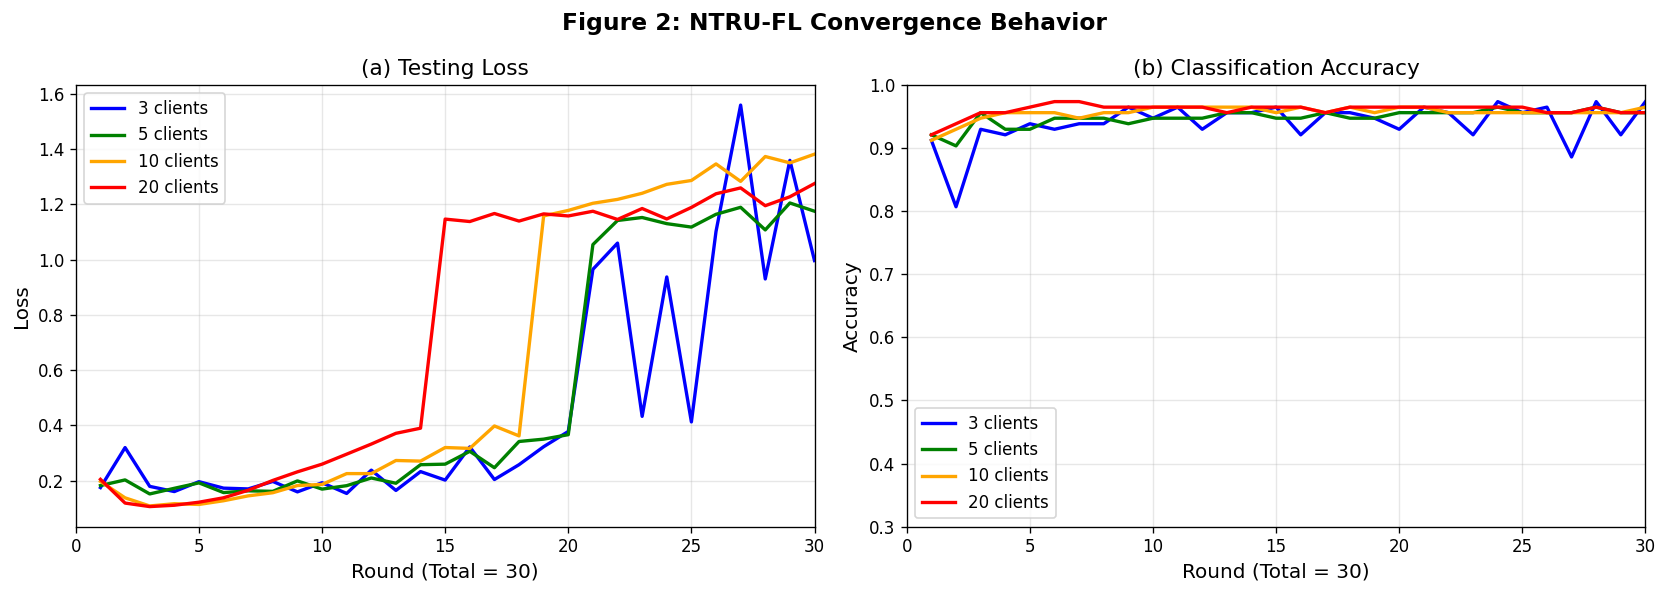

Figure saved to /content/drive/MyDrive/ntru_fl_v0/figure2.png


In [25]:
# Cell 20 — Figure 2
colors = {3:'blue', 5:'green', 10:'orange', 20:'red'}
rounds = list(range(1, NUM_ROUNDS+1))
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for nc in CLIENT_COUNTS:
    axes[0].plot(rounds, ntru_results[nc]['loss_curve'], label=f'{nc} clients', color=colors[nc], lw=2)
    axes[1].plot(rounds, ntru_results[nc]['acc_curve'],  label=f'{nc} clients', color=colors[nc], lw=2)
for ax, title, ylabel in [
    (axes[0], '(a) Testing Loss',           'Loss'),
    (axes[1], '(b) Classification Accuracy','Accuracy')]:
    ax.set_xlabel('Round (Total = 30)', fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(title, fontsize=13)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, 30)
axes[1].set_ylim(0.3, 1.0)
plt.suptitle('Figure 2: NTRU-FL Convergence Behavior', fontsize=14, fontweight='bold')
plt.tight_layout()
fig_path = os.path.join(SAVE_DIR, 'figure2.png')
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Figure saved to {fig_path}')

In [26]:
# Cell 21 — Final Summary
print('='*65)
print('FULL EXPERIMENT SUMMARY')
print('='*65)
print('\n[Table 7]')
for label, res in [('Plain-FL', plain_results), ('NTRU-FL', ntru_results)]:
    row = f'{label:<10}'
    for nc in CLIENT_COUNTS:
        r = res[nc]
        acc = r.get('acc', r.get('final_acc'))
        f1  = r.get('f1',  r.get('final_f1'))
        row += f'  {nc}c:{acc:.4f}/{f1:.4f}'
    print(row)
print('\n[Table 8 — Cumulative ms]')
for nc in CLIENT_COUNTS:
    r = ntru_results[nc]
    print(f'  {nc:>2}c | enc={r["total_enc_ms"]:>10,.1f} | dec={r["total_dec_ms"]:>10,.1f} | total={r["total_latency_ms"]:>10,.1f}')
print('\n[Table 9 — Per-client ms]')
for nc in CLIENT_COUNTS:
    r = ntru_results[nc]
    print(f'  {nc:>2}c | enc {r["enc_max_ms"]:>8.1f}/{r["enc_min_ms"]:<8.1f} | dec {r["dec_max_ms"]:>8.1f}/{r["dec_min_ms"]:<8.1f}')
print(f'\nAll saved to {RESULTS_PATH}')
print('Done!')

FULL EXPERIMENT SUMMARY

[Table 7]
Plain-FL    3c:0.9737/0.9790  5c:0.9561/0.9645  10c:0.9649/0.9718  20c:0.9561/0.9655
NTRU-FL     3c:0.9737/0.9790  5c:0.9561/0.9645  10c:0.9649/0.9718  20c:0.9561/0.9645

[Table 8 — Cumulative ms]
   3c | enc= 225,880.6 | dec= 422,554.9 | total= 648,435.5
   5c | enc= 372,375.5 | dec= 699,391.8 | total=1,071,767.3
  10c | enc= 746,639.8 | dec=1,399,203.8 | total=2,145,843.6
  20c | enc=1,484,908.7 | dec=2,580,400.6 | total=4,065,309.4

[Table 9 — Per-client ms]
   3c | enc   3829.8/2075.7   | dec   6889.4/3967.9  
   5c | enc   4043.3/2071.9   | dec   6112.5/3967.1  
  10c | enc   4062.6/2068.2   | dec   7336.9/2567.2  
  20c | enc   4093.5/2068.8   | dec   6286.3/2067.0  

All saved to /content/drive/MyDrive/ntru_fl_v0/results.json
Done!
